In [1]:
import os
import pandas as pd

# 当前 notebook 位于: 04_api_and_plotting/
project_root = ".."

input_csv = os.path.join(
    project_root,
    "01_dataset1_text",
    "02_cleaning",
    "cleaned_csv",
    "dataset1_cleaned_final.csv"
)

outputs_dir = os.path.join(".", "outputs")
os.makedirs(outputs_dir, exist_ok=True)

print("Input CSV:", input_csv)
print("Outputs dir:", outputs_dir)

df = pd.read_csv(input_csv)
print("Rows:", len(df))
print("Columns:", list(df.columns))

display(df.head(5))

Input CSV: ..\01_dataset1_text\02_cleaning\cleaned_csv\dataset1_cleaned_final.csv
Outputs dir: .\outputs
Rows: 265
Columns: ['query', 'video_id', 'title', 'channel', 'duration', 'view_count', 'upload_date', 'url', 'webpage_url', 'query_clean', 'title_clean', 'channel_clean', 'boundary_score', 'sound_score', 'noise_score', 'keep_initial']


,query,video_id,title,channel,duration,view_count,upload_date,url,webpage_url,query_clean,title_clean,channel_clean,boundary_score,sound_score,noise_score,keep_initial
0,bird warning call,dvK-DujvpSY,White bellbird: listen to the world's loudest ...,Guardian News,31.0,9885069.0,NaN,https://www.youtube.com/watch?v=dvK-DujvpSY,NaN,bird warning call,white bellbird listen to the world s loudest b...,guardian news,0,1,0,True
1,bird warning call,cPIIVjkp7k0,Bluebird Alarm Call,Wild Birds Unlimited Macomb,12.0,26065.0,NaN,https://www.youtube.com/watch?v=cPIIVjkp7k0,NaN,bird warning call,bluebird alarm call,wild birds unlimited macomb,1,1,0,True
2,bird warning call,ga_Ybn_K4rc,Chickadee alarm call (16 alarm call at the end!),Bird Feeder Hub,29.0,13511.0,NaN,https://www.youtube.com/watch?v=ga_Ybn_K4rc,NaN,bird warning call,chickadee alarm call 16 alarm call at the end,bird feeder hub,1,1,0,True
3,bird warning call,uuxTZN98rHI,"5 bird alarm calls: blackbird, wren, blackcap,...",Watch the Birdie,96.0,30788.0,NaN,https://www.youtube.com/watch?v=uuxTZN98rHI,NaN,bird warning call,5 bird alarm calls blackbird wren blackcap thr...,watch the birdie,1,2,0,True
4,bird warning call,2aFIujmqJfI,Bird Calls: Is That An Alarm?,NatureMentor,369.0,2894.0,NaN,https://www.youtube.com/watch?v=2aFIujmqJfI,NaN,bird warning call,bird calls is that an alarm,naturementor,1,2,0,True


In [2]:
needed_cols = ["query", "title"]

for col in needed_cols:
    print(col, "exists ->", col in df.columns)

display(df[needed_cols].head(10))

query exists -> True
title exists -> True


,query,title
0,bird warning call,White bellbird: listen to the world's loudest ...
1,bird warning call,Bluebird Alarm Call
2,bird warning call,Chickadee alarm call (16 alarm call at the end!)
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,..."
4,bird warning call,Bird Calls: Is That An Alarm?
5,bird warning call,Blackbird alarm call
6,bird warning call,Decoding bird calls: What they are REALLY Saying?
7,bird warning call,Loud American Robin Alarm Warning Call - Robin...
8,bird warning call,Anti Birds Repellent Sound - calls of birds of...
9,bird warning call,Cardinal Bird-Calling Sounds promo


In [3]:
df_api_test = df[["query", "title"]].dropna().head(5).copy()
df_api_test = df_api_test.reset_index(drop=True)

print("Test rows:", len(df_api_test))
display(df_api_test)

Test rows: 5


,query,title
0,bird warning call,White bellbird: listen to the world's loudest ...
1,bird warning call,Bluebird Alarm Call
2,bird warning call,Chickadee alarm call (16 alarm call at the end!)
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,..."
4,bird warning call,Bird Calls: Is That An Alarm?


In [4]:
PRIMARY_LABELS = [
    "warning",
    "territory",
    "repel",
    "approach",
    "alarm",
    "communication",
    "unknown"
]

SECONDARY_LABELS = [
    "bird",
    "animal",
    "predator",
    "social_signal",
    "defence",
    "distress",
    "unknown"
]

BOUNDARY_STATES = [
    "formed",
    "activated",
    "broken",
    "unclear"
]

INTENSITY_LEVELS = [
    "low",
    "medium",
    "high",
    "unclear"
]

print("Primary labels:", PRIMARY_LABELS)
print("Secondary labels:", SECONDARY_LABELS)
print("Boundary states:", BOUNDARY_STATES)
print("Intensity levels:", INTENSITY_LEVELS)

Primary labels: ['warning', 'territory', 'repel', 'approach', 'alarm', 'communication', 'unknown']
Secondary labels: ['bird', 'animal', 'predator', 'social_signal', 'defence', 'distress', 'unknown']
Boundary states: ['formed', 'activated', 'broken', 'unclear']
Intensity levels: ['low', 'medium', 'high', 'unclear']


In [5]:
%pip install openai -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from getpass import getpass
import os
import json
import pandas as pd
from openai import OpenAI

In [8]:
api_key = getpass("Paste your OpenAI API key here: ")

os.environ["OPENAI_API_KEY"] = api_key
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

print("API client created successfully.")

Paste your OpenAI API key here:  ········


API client created successfully.


In [11]:
def classify_boundary_title(query, title):
    schema = {
        "type": "object",
        "properties": {
            "primary_boundary_label": {
                "type": "string",
                "enum": PRIMARY_LABELS
            },
            "secondary_boundary_label": {
                "type": "string",
                "enum": SECONDARY_LABELS
            },
            "boundary_state": {
                "type": "string",
                "enum": BOUNDARY_STATES
            },
            "intensity_level": {
                "type": "string",
                "enum": INTENSITY_LEVELS
            },
            "reason_short": {
                "type": "string"
            }
        },
        "required": [
            "primary_boundary_label",
            "secondary_boundary_label",
            "boundary_state",
            "intensity_level",
            "reason_short"
        ],
        "additionalProperties": False
    }

    prompt = f"""
Classify this YouTube item for a design research dataset about sound, warning, territoriality, and spatial boundaries.

Input query: {query}
Input title: {title}

Choose only from the provided schema enums.
Keep reason_short under 20 words.
""".strip()

    response = client.responses.create(
        model="gpt-4o-mini",
        input=prompt,
        text={
            "format": {
                "type": "json_schema",
                "strict": True,
                "name": "boundary_label_result",
                "schema": schema
            }
        }
    )

    raw_text = response.output_text.strip()
    print("RAW RESPONSE:")
    print(raw_text)

    return json.loads(raw_text)

In [12]:
test_row = df_api_test.iloc[0]

print("QUERY:", test_row["query"])
print("TITLE:", test_row["title"])

test_result = classify_boundary_title(
    query=test_row["query"],
    title=test_row["title"]
)

print(test_result)

QUERY: bird warning call
TITLE: White bellbird: listen to the world's loudest bird call
RAW RESPONSE:
{"primary_boundary_label":"warning","secondary_boundary_label":"bird","boundary_state":"activated","intensity_level":"high","reason_short":"Loud call serves as a warning signal."}
{'primary_boundary_label': 'warning', 'secondary_boundary_label': 'bird', 'boundary_state': 'activated', 'intensity_level': 'high', 'reason_short': 'Loud call serves as a warning signal.'}


In [13]:
results_test = []

for i, row in df_api_test.iterrows():
    try:
        result = classify_boundary_title(
            query=row["query"],
            title=row["title"]
        )

        results_test.append({
            "query": row["query"],
            "title": row["title"],
            "primary_boundary_label": result["primary_boundary_label"],
            "secondary_boundary_label": result["secondary_boundary_label"],
            "boundary_state": result["boundary_state"],
            "intensity_level": result["intensity_level"],
            "reason_short": result["reason_short"],
            "status": "ok"
        })

    except Exception as e:
        results_test.append({
            "query": row["query"],
            "title": row["title"],
            "primary_boundary_label": None,
            "secondary_boundary_label": None,
            "boundary_state": None,
            "intensity_level": None,
            "reason_short": None,
            "status": f"error: {str(e)}"
        })

df_api_test_results = pd.DataFrame(results_test)

print("Processed rows:", len(df_api_test_results))
display(df_api_test_results)

RAW RESPONSE:
{"primary_boundary_label":"warning","secondary_boundary_label":"bird","boundary_state":"formed","intensity_level":"high","reason_short":"Loud call signals danger to others."}
RAW RESPONSE:
{"primary_boundary_label":"alarm","secondary_boundary_label":"social_signal","boundary_state":"activated","intensity_level":"high","reason_short":"Bluebird call indicates a warning for predators."}
RAW RESPONSE:
{"primary_boundary_label":"warning","secondary_boundary_label":"social_signal","boundary_state":"activated","intensity_level":"high","reason_short":"Chickadee alarm indicates potential threats."}
RAW RESPONSE:
{"primary_boundary_label":"alarm","secondary_boundary_label":"bird","boundary_state":"formed","intensity_level":"medium","reason_short":"Birds issuing warning calls for territory and safety."}
RAW RESPONSE:
{"primary_boundary_label":"warning","secondary_boundary_label":"social_signal","boundary_state":"activated","intensity_level":"medium","reason_short":"Indicates alarm c

,query,title,primary_boundary_label,secondary_boundary_label,boundary_state,intensity_level,reason_short,status
0,bird warning call,White bellbird: listen to the world's loudest ...,warning,bird,formed,high,Loud call signals danger to others.,ok
1,bird warning call,Bluebird Alarm Call,alarm,social_signal,activated,high,Bluebird call indicates a warning for predators.,ok
2,bird warning call,Chickadee alarm call (16 alarm call at the end!),warning,social_signal,activated,high,Chickadee alarm indicates potential threats.,ok
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,...",alarm,bird,formed,medium,Birds issuing warning calls for territory and ...,ok
4,bird warning call,Bird Calls: Is That An Alarm?,warning,social_signal,activated,medium,Indicates alarm calls from birds.,ok


In [14]:
test_output_file = os.path.join(outputs_dir, "dataset1_api_boundary_labels_test5.csv")
df_api_test_results.to_csv(test_output_file, index=False, encoding="utf-8-sig")

print("Saved file:", test_output_file)

Saved file: .\outputs\dataset1_api_boundary_labels_test5.csv


In [1]:
PRIMARY_LABELS = [
    "warning",
    "territory",
    "repellent",
    "unclear"
]

SECONDARY_LABELS = [
    "bird",
    "animal",
    "artificial_sound",
    "unclear"
]

BOUNDARY_STATES = [
    "explicit",
    "possible",
    "unclear"
]

INTENSITY_LEVELS = [
    "low",
    "medium",
    "high",
    "unclear"
]

print("Primary labels:", PRIMARY_LABELS)
print("Secondary labels:", SECONDARY_LABELS)
print("Boundary states:", BOUNDARY_STATES)
print("Intensity levels:", INTENSITY_LEVELS)

Primary labels: ['warning', 'territory', 'repellent', 'unclear']
Secondary labels: ['bird', 'animal', 'artificial_sound', 'unclear']
Boundary states: ['explicit', 'possible', 'unclear']
Intensity levels: ['low', 'medium', 'high', 'unclear']


In [2]:
def classify_boundary_title(query, title):
    schema = {
        "type": "object",
        "properties": {
            "primary_boundary_label": {
                "type": "string",
                "enum": PRIMARY_LABELS
            },
            "secondary_boundary_label": {
                "type": "string",
                "enum": SECONDARY_LABELS
            },
            "boundary_state": {
                "type": "string",
                "enum": BOUNDARY_STATES
            },
            "intensity_level": {
                "type": "string",
                "enum": INTENSITY_LEVELS
            },
            "reason_short": {
                "type": "string"
            }
        },
        "required": [
            "primary_boundary_label",
            "secondary_boundary_label",
            "boundary_state",
            "intensity_level",
            "reason_short"
        ],
        "additionalProperties": False
    }

    prompt = f"""
You are classifying YouTube titles for a design research dataset about sound, warning, territoriality, deterrence, and spatial boundaries.

Use the following rules:

PRIMARY LABEL:
- warning = alarm, alert, distress, threat, predator warning
- territory = territorial claim, ownership, keep-away signalling
- repellent = deterrent, anti-bird sound, scare sound, artificial repelling sound
- unclear = title is too vague

SECONDARY LABEL:
- bird = clearly bird-related
- animal = clearly animal-related but not specifically bird
- artificial_sound = clearly man-made deterrent / anti-bird / artificial signal
- unclear = cannot tell

BOUNDARY STATE:
- explicit = title directly signals boundary behaviour (alarm, warning, territorial, repellent)
- possible = title suggests it indirectly
- unclear = cannot tell

INTENSITY:
- high = strong alarm / warning / aggressive / urgent
- medium = clear but not extreme
- low = weak / neutral / soft
- unclear = cannot tell

Input query: {query}
Input title: {title}

Return only valid JSON matching the schema.
Keep reason_short under 20 words.
""".strip()

    response = client.responses.create(
        model="gpt-4o-mini",
        input=prompt,
        text={
            "format": {
                "type": "json_schema",
                "strict": True,
                "name": "boundary_label_result",
                "schema": schema
            }
        }
    )

    raw_text = response.output_text.strip()
    print("RAW RESPONSE:")
    print(raw_text)

    return json.loads(raw_text)

In [3]:
test_row = df_api_test.iloc[0]

print("QUERY:", test_row["query"])
print("TITLE:", test_row["title"])

test_result = classify_boundary_title(
    query=test_row["query"],
    title=test_row["title"]
)

print(test_result)

NameError: name 'df_api_test' is not defined

In [4]:
df_api_test = df[["query", "title"]].dropna().head(5).copy()
df_api_test = df_api_test.reset_index(drop=True)

print("Test rows:", len(df_api_test))
display(df_api_test)

NameError: name 'df' is not defined

In [5]:
import os
import pandas as pd

project_root = ".."

input_csv = os.path.join(
    project_root,
    "01_dataset1_text",
    "02_cleaning",
    "cleaned_csv",
    "dataset1_cleaned_final.csv"
)

outputs_dir = os.path.join(".", "outputs")
os.makedirs(outputs_dir, exist_ok=True)

df = pd.read_csv(input_csv)

print("Rows:", len(df))
print("Columns:", list(df.columns))
display(df.head(5))

Rows: 265
Columns: ['query', 'video_id', 'title', 'channel', 'duration', 'view_count', 'upload_date', 'url', 'webpage_url', 'query_clean', 'title_clean', 'channel_clean', 'boundary_score', 'sound_score', 'noise_score', 'keep_initial']


,query,video_id,title,channel,duration,view_count,upload_date,url,webpage_url,query_clean,title_clean,channel_clean,boundary_score,sound_score,noise_score,keep_initial
0,bird warning call,dvK-DujvpSY,White bellbird: listen to the world's loudest ...,Guardian News,31.0,9885069.0,NaN,https://www.youtube.com/watch?v=dvK-DujvpSY,NaN,bird warning call,white bellbird listen to the world s loudest b...,guardian news,0,1,0,True
1,bird warning call,cPIIVjkp7k0,Bluebird Alarm Call,Wild Birds Unlimited Macomb,12.0,26065.0,NaN,https://www.youtube.com/watch?v=cPIIVjkp7k0,NaN,bird warning call,bluebird alarm call,wild birds unlimited macomb,1,1,0,True
2,bird warning call,ga_Ybn_K4rc,Chickadee alarm call (16 alarm call at the end!),Bird Feeder Hub,29.0,13511.0,NaN,https://www.youtube.com/watch?v=ga_Ybn_K4rc,NaN,bird warning call,chickadee alarm call 16 alarm call at the end,bird feeder hub,1,1,0,True
3,bird warning call,uuxTZN98rHI,"5 bird alarm calls: blackbird, wren, blackcap,...",Watch the Birdie,96.0,30788.0,NaN,https://www.youtube.com/watch?v=uuxTZN98rHI,NaN,bird warning call,5 bird alarm calls blackbird wren blackcap thr...,watch the birdie,1,2,0,True
4,bird warning call,2aFIujmqJfI,Bird Calls: Is That An Alarm?,NatureMentor,369.0,2894.0,NaN,https://www.youtube.com/watch?v=2aFIujmqJfI,NaN,bird warning call,bird calls is that an alarm,naturementor,1,2,0,True


In [6]:
df_api_test = df[["query", "title"]].dropna().head(5).copy()
df_api_test = df_api_test.reset_index(drop=True)

print("Test rows:", len(df_api_test))
display(df_api_test)

Test rows: 5


,query,title
0,bird warning call,White bellbird: listen to the world's loudest ...
1,bird warning call,Bluebird Alarm Call
2,bird warning call,Chickadee alarm call (16 alarm call at the end!)
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,..."
4,bird warning call,Bird Calls: Is That An Alarm?


In [7]:
test_row = df_api_test.iloc[0]

print("QUERY:", test_row["query"])
print("TITLE:", test_row["title"])

test_result = classify_boundary_title(
    query=test_row["query"],
    title=test_row["title"]
)

print(test_result)

QUERY: bird warning call
TITLE: White bellbird: listen to the world's loudest bird call


NameError: name 'client' is not defined

In [8]:
from getpass import getpass
import os
import json
import pandas as pd
from openai import OpenAI

In [9]:
api_key = getpass("Paste your OpenAI API key here: ")

os.environ["OPENAI_API_KEY"] = api_key
client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

print("API client created successfully.")

Paste your OpenAI API key here:  ········


API client created successfully.


In [10]:
test_row = df_api_test.iloc[0]

print("QUERY:", test_row["query"])
print("TITLE:", test_row["title"])

test_result = classify_boundary_title(
    query=test_row["query"],
    title=test_row["title"]
)

print(test_result)

QUERY: bird warning call
TITLE: White bellbird: listen to the world's loudest bird call
RAW RESPONSE:
{"primary_boundary_label":"warning","secondary_boundary_label":"bird","boundary_state":"explicit","intensity_level":"high","reason_short":"Directly relates to bird's loud warning call."}
{'primary_boundary_label': 'warning', 'secondary_boundary_label': 'bird', 'boundary_state': 'explicit', 'intensity_level': 'high', 'reason_short': "Directly relates to bird's loud warning call."}


In [11]:
results_test_v2 = []

for i, row in df_api_test.iterrows():
    try:
        result = classify_boundary_title(
            query=row["query"],
            title=row["title"]
        )

        results_test_v2.append({
            "query": row["query"],
            "title": row["title"],
            "primary_boundary_label": result["primary_boundary_label"],
            "secondary_boundary_label": result["secondary_boundary_label"],
            "boundary_state": result["boundary_state"],
            "intensity_level": result["intensity_level"],
            "reason_short": result["reason_short"],
            "status": "ok"
        })

    except Exception as e:
        results_test_v2.append({
            "query": row["query"],
            "title": row["title"],
            "primary_boundary_label": None,
            "secondary_boundary_label": None,
            "boundary_state": None,
            "intensity_level": None,
            "reason_short": None,
            "status": f"error: {str(e)}"
        })

df_api_test_results_v2 = pd.DataFrame(results_test_v2)

print("Processed rows:", len(df_api_test_results_v2))
display(df_api_test_results_v2)

RAW RESPONSE:
{"primary_boundary_label":"warning","secondary_boundary_label":"bird","boundary_state":"explicit","intensity_level":"high","reason_short":"Title mentions a loud warning call."}
RAW RESPONSE:
{"primary_boundary_label":"warning","secondary_boundary_label":"bird","boundary_state":"explicit","intensity_level":"high","reason_short":"Title indicates a clear alarm sound from a bird."}
RAW RESPONSE:
{"primary_boundary_label":"warning","secondary_boundary_label":"bird","boundary_state":"explicit","intensity_level":"high","reason_short":"Title indicates a clear alarm call."}
RAW RESPONSE:
{"primary_boundary_label":"warning","secondary_boundary_label":"bird","boundary_state":"explicit","intensity_level":"medium","reason_short":"Title describes alarm calls of birds."}
RAW RESPONSE:
{"primary_boundary_label":"warning","secondary_boundary_label":"bird","boundary_state":"explicit","intensity_level":"medium","reason_short":"Directly refers to alarm in bird calls."}
Processed rows: 5


,query,title,primary_boundary_label,secondary_boundary_label,boundary_state,intensity_level,reason_short,status
0,bird warning call,White bellbird: listen to the world's loudest ...,warning,bird,explicit,high,Title mentions a loud warning call.,ok
1,bird warning call,Bluebird Alarm Call,warning,bird,explicit,high,Title indicates a clear alarm sound from a bird.,ok
2,bird warning call,Chickadee alarm call (16 alarm call at the end!),warning,bird,explicit,high,Title indicates a clear alarm call.,ok
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,...",warning,bird,explicit,medium,Title describes alarm calls of birds.,ok
4,bird warning call,Bird Calls: Is That An Alarm?,warning,bird,explicit,medium,Directly refers to alarm in bird calls.,ok


In [12]:
test_output_file_v2 = os.path.join(outputs_dir, "dataset1_api_boundary_labels_test5_v2.csv")
df_api_test_results_v2.to_csv(test_output_file_v2, index=False, encoding="utf-8-sig")

print("Saved file:", test_output_file_v2)

Saved file: .\outputs\dataset1_api_boundary_labels_test5_v2.csv


In [13]:
display(df_api_test_results_v2["primary_boundary_label"].value_counts())
display(df_api_test_results_v2["secondary_boundary_label"].value_counts())
display(df_api_test_results_v2["boundary_state"].value_counts())
display(df_api_test_results_v2["status"].value_counts())

primary_boundary_label
warning    5
Name: count, dtype: int64

secondary_boundary_label
bird    5
Name: count, dtype: int64

boundary_state
explicit    5
Name: count, dtype: int64

status
ok    5
Name: count, dtype: int64

In [14]:
query_counts = df["query"].value_counts()
display(query_counts)

query
bird warning call             69
alarm call animal             65
territorial animal sound      61
animal warning sound urban    43
territorial bird call         27
Name: count, dtype: int64

In [15]:
top_queries = df["query"].value_counts().head(4).index.tolist()
print("Top queries:", top_queries)

df_api_batch20 = (
    df[df["query"].isin(top_queries)][["query", "title"]]
    .dropna()
    .groupby("query", group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

print("Batch rows:", len(df_api_batch20))
display(df_api_batch20)

Top queries: ['bird warning call', 'alarm call animal', 'territorial animal sound', 'animal warning sound urban']
Batch rows: 20


,query,title
0,bird warning call,White bellbird: listen to the world's loudest ...
1,bird warning call,Bluebird Alarm Call
2,bird warning call,Chickadee alarm call (16 alarm call at the end!)
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,..."
4,bird warning call,Bird Calls: Is That An Alarm?
5,alarm call animal,Monkeys Sound Alarm To Save Deer From A Tiger ...
6,alarm call animal,Sounding the Prairie Dog Alert System | Americ...
7,alarm call animal,Sambar Deer Alarm Call - Ranthambore National ...
8,alarm call animal,Understanding Alarm Calls to find a Tiger in W...
9,alarm call animal,"Tiger or Leopard, how to find out by Alarm Cal..."


In [16]:
results_batch20_v2 = []

for i, row in df_api_batch20.iterrows():
    try:
        result = classify_boundary_title(
            query=row["query"],
            title=row["title"]
        )

        results_batch20_v2.append({
            "query": row["query"],
            "title": row["title"],
            "primary_boundary_label": result["primary_boundary_label"],
            "secondary_boundary_label": result["secondary_boundary_label"],
            "boundary_state": result["boundary_state"],
            "intensity_level": result["intensity_level"],
            "reason_short": result["reason_short"],
            "status": "ok"
        })

    except Exception as e:
        results_batch20_v2.append({
            "query": row["query"],
            "title": row["title"],
            "primary_boundary_label": None,
            "secondary_boundary_label": None,
            "boundary_state": None,
            "intensity_level": None,
            "reason_short": None,
            "status": f"error: {str(e)}"
        })

df_api_batch20_results_v2 = pd.DataFrame(results_batch20_v2)

print("Processed rows:", len(df_api_batch20_results_v2))
display(df_api_batch20_results_v2)

RAW RESPONSE:
{"primary_boundary_label":"warning","secondary_boundary_label":"bird","boundary_state":"explicit","intensity_level":"high","reason_short":"Title features a warning call from a bird."}
RAW RESPONSE:
{"primary_boundary_label":"warning","secondary_boundary_label":"bird","boundary_state":"explicit","intensity_level":"high","reason_short":"Title indicates a strong alarm from a bird."}
RAW RESPONSE:
{"primary_boundary_label":"warning","secondary_boundary_label":"bird","boundary_state":"explicit","intensity_level":"high","reason_short":"Direct alarm call from a bird."}
RAW RESPONSE:
{"primary_boundary_label":"warning","secondary_boundary_label":"bird","boundary_state":"explicit","intensity_level":"medium","reason_short":"Title lists bird alarm calls."}
RAW RESPONSE:
{"primary_boundary_label":"warning","secondary_boundary_label":"bird","boundary_state":"explicit","intensity_level":"medium","reason_short":"Title indicates alarm from bird calls."}
RAW RESPONSE:
{"primary_boundary_l

,query,title,primary_boundary_label,secondary_boundary_label,boundary_state,intensity_level,reason_short,status
0,bird warning call,White bellbird: listen to the world's loudest ...,warning,bird,explicit,high,Title features a warning call from a bird.,ok
1,bird warning call,Bluebird Alarm Call,warning,bird,explicit,high,Title indicates a strong alarm from a bird.,ok
2,bird warning call,Chickadee alarm call (16 alarm call at the end!),warning,bird,explicit,high,Direct alarm call from a bird.,ok
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,...",warning,bird,explicit,medium,Title lists bird alarm calls.,ok
4,bird warning call,Bird Calls: Is That An Alarm?,warning,bird,explicit,medium,Title indicates alarm from bird calls.,ok
5,alarm call animal,Monkeys Sound Alarm To Save Deer From A Tiger ...,warning,animal,explicit,high,Directly signals alarm to save another animal.,ok
6,alarm call animal,Sounding the Prairie Dog Alert System | Americ...,warning,animal,explicit,high,Directly signals alarm system for prairie dogs.,ok
7,alarm call animal,Sambar Deer Alarm Call - Ranthambore National ...,warning,animal,explicit,high,Title indicates strong alarm behavior.,ok
8,alarm call animal,Understanding Alarm Calls to find a Tiger in W...,warning,animal,explicit,high,Title indicates strong alarm for a predator.,ok
9,alarm call animal,"Tiger or Leopard, how to find out by Alarm Cal...",warning,animal,explicit,medium,Title indicates alarm calls related to animals.,ok


In [17]:
batch20_output_file_v2 = os.path.join(outputs_dir, "dataset1_api_boundary_labels_batch20_v2.csv")
df_api_batch20_results_v2.to_csv(batch20_output_file_v2, index=False, encoding="utf-8-sig")

print("Saved file:", batch20_output_file_v2)

Saved file: .\outputs\dataset1_api_boundary_labels_batch20_v2.csv


In [18]:
display(df_api_batch20_results_v2["query"].value_counts())
display(df_api_batch20_results_v2["primary_boundary_label"].value_counts())
display(df_api_batch20_results_v2["secondary_boundary_label"].value_counts())
display(df_api_batch20_results_v2["boundary_state"].value_counts())
display(df_api_batch20_results_v2["status"].value_counts())

query
bird warning call             5
alarm call animal             5
animal warning sound urban    5
territorial animal sound      5
Name: count, dtype: int64

primary_boundary_label
warning      15
territory     5
Name: count, dtype: int64

secondary_boundary_label
animal    15
bird       5
Name: count, dtype: int64

boundary_state
explicit    19
possible     1
Name: count, dtype: int64

status
ok    20
Name: count, dtype: int64

In [19]:
df_api_batch20_results_v2 = pd.DataFrame(results_batch20_v2)

print("Processed rows:", len(df_api_batch20_results_v2))
display(df_api_batch20_results_v2)

Processed rows: 20


,query,title,primary_boundary_label,secondary_boundary_label,boundary_state,intensity_level,reason_short,status
0,bird warning call,White bellbird: listen to the world's loudest ...,warning,bird,explicit,high,Title features a warning call from a bird.,ok
1,bird warning call,Bluebird Alarm Call,warning,bird,explicit,high,Title indicates a strong alarm from a bird.,ok
2,bird warning call,Chickadee alarm call (16 alarm call at the end!),warning,bird,explicit,high,Direct alarm call from a bird.,ok
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,...",warning,bird,explicit,medium,Title lists bird alarm calls.,ok
4,bird warning call,Bird Calls: Is That An Alarm?,warning,bird,explicit,medium,Title indicates alarm from bird calls.,ok
5,alarm call animal,Monkeys Sound Alarm To Save Deer From A Tiger ...,warning,animal,explicit,high,Directly signals alarm to save another animal.,ok
6,alarm call animal,Sounding the Prairie Dog Alert System | Americ...,warning,animal,explicit,high,Directly signals alarm system for prairie dogs.,ok
7,alarm call animal,Sambar Deer Alarm Call - Ranthambore National ...,warning,animal,explicit,high,Title indicates strong alarm behavior.,ok
8,alarm call animal,Understanding Alarm Calls to find a Tiger in W...,warning,animal,explicit,high,Title indicates strong alarm for a predator.,ok
9,alarm call animal,"Tiger or Leopard, how to find out by Alarm Cal...",warning,animal,explicit,medium,Title indicates alarm calls related to animals.,ok


In [20]:
batch20_output_file_v2 = os.path.join(outputs_dir, "dataset1_api_boundary_labels_batch20_v2.csv")
df_api_batch20_results_v2.to_csv(batch20_output_file_v2, index=False, encoding="utf-8-sig")

print("Saved file:", batch20_output_file_v2)

Saved file: .\outputs\dataset1_api_boundary_labels_batch20_v2.csv


In [21]:
display(df_api_batch20_results_v2["query"].value_counts())
display(df_api_batch20_results_v2["primary_boundary_label"].value_counts())
display(df_api_batch20_results_v2["secondary_boundary_label"].value_counts())
display(df_api_batch20_results_v2["boundary_state"].value_counts())
display(df_api_batch20_results_v2["intensity_level"].value_counts())
display(df_api_batch20_results_v2["status"].value_counts())

query
bird warning call             5
alarm call animal             5
animal warning sound urban    5
territorial animal sound      5
Name: count, dtype: int64

primary_boundary_label
warning      15
territory     5
Name: count, dtype: int64

secondary_boundary_label
animal    15
bird       5
Name: count, dtype: int64

boundary_state
explicit    19
possible     1
Name: count, dtype: int64

intensity_level
medium    11
high       9
Name: count, dtype: int64

status
ok    20
Name: count, dtype: int64

In [22]:
def classify_boundary_title_quiet(query, title):
    schema = {
        "type": "object",
        "properties": {
            "primary_boundary_label": {
                "type": "string",
                "enum": PRIMARY_LABELS
            },
            "secondary_boundary_label": {
                "type": "string",
                "enum": SECONDARY_LABELS
            },
            "boundary_state": {
                "type": "string",
                "enum": BOUNDARY_STATES
            },
            "intensity_level": {
                "type": "string",
                "enum": INTENSITY_LEVELS
            },
            "reason_short": {
                "type": "string"
            }
        },
        "required": [
            "primary_boundary_label",
            "secondary_boundary_label",
            "boundary_state",
            "intensity_level",
            "reason_short"
        ],
        "additionalProperties": False
    }

    prompt = f"""
You are classifying YouTube titles for a design research dataset about sound, warning, territoriality, deterrence, and spatial boundaries.

Use the following rules:

PRIMARY LABEL:
- warning = alarm, alert, distress, threat, predator warning
- territory = territorial claim, ownership, keep-away signalling
- repellent = deterrent, anti-bird sound, scare sound, artificial repelling sound
- unclear = title is too vague

SECONDARY LABEL:
- bird = clearly bird-related
- animal = clearly animal-related but not specifically bird
- artificial_sound = clearly man-made deterrent / anti-bird / artificial signal
- unclear = cannot tell

BOUNDARY STATE:
- explicit = title directly signals boundary behaviour (alarm, warning, territorial, repellent)
- possible = title suggests it indirectly
- unclear = cannot tell

INTENSITY:
- high = strong alarm / warning / aggressive / urgent
- medium = clear but not extreme
- low = weak / neutral / soft
- unclear = cannot tell

Input query: {query}
Input title: {title}

Return only valid JSON matching the schema.
Keep reason_short under 20 words.
""".strip()

    response = client.responses.create(
        model="gpt-4o-mini",
        input=prompt,
        text={
            "format": {
                "type": "json_schema",
                "strict": True,
                "name": "boundary_label_result",
                "schema": schema
            }
        }
    )

    raw_text = response.output_text.strip()
    return json.loads(raw_text)

In [23]:
df_api_full = df[["query", "title"]].dropna().copy()
df_api_full = df_api_full.reset_index(drop=True)

print("Full rows:", len(df_api_full))
display(df_api_full.head(10))

Full rows: 265


,query,title
0,bird warning call,White bellbird: listen to the world's loudest ...
1,bird warning call,Bluebird Alarm Call
2,bird warning call,Chickadee alarm call (16 alarm call at the end!)
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,..."
4,bird warning call,Bird Calls: Is That An Alarm?
5,bird warning call,Blackbird alarm call
6,bird warning call,Decoding bird calls: What they are REALLY Saying?
7,bird warning call,Loud American Robin Alarm Warning Call - Robin...
8,bird warning call,Anti Birds Repellent Sound - calls of birds of...
9,bird warning call,Cardinal Bird-Calling Sounds promo


In [24]:
results_full_v2 = []

for i, row in df_api_full.iterrows():
    try:
        result = classify_boundary_title_quiet(
            query=row["query"],
            title=row["title"]
        )

        results_full_v2.append({
            "query": row["query"],
            "title": row["title"],
            "primary_boundary_label": result["primary_boundary_label"],
            "secondary_boundary_label": result["secondary_boundary_label"],
            "boundary_state": result["boundary_state"],
            "intensity_level": result["intensity_level"],
            "reason_short": result["reason_short"],
            "status": "ok"
        })

    except Exception as e:
        results_full_v2.append({
            "query": row["query"],
            "title": row["title"],
            "primary_boundary_label": None,
            "secondary_boundary_label": None,
            "boundary_state": None,
            "intensity_level": None,
            "reason_short": None,
            "status": f"error: {str(e)}"
        })

    if (i + 1) % 25 == 0:
        checkpoint_df = pd.DataFrame(results_full_v2)
        checkpoint_file = os.path.join(
            outputs_dir,
            f"dataset1_api_boundary_labels_checkpoint_{i+1}.csv"
        )
        checkpoint_df.to_csv(checkpoint_file, index=False, encoding="utf-8-sig")
        print(f"Checkpoint saved at row {i+1}: {checkpoint_file}")

print("Finished full run.")

Checkpoint saved at row 25: .\outputs\dataset1_api_boundary_labels_checkpoint_25.csv
Checkpoint saved at row 50: .\outputs\dataset1_api_boundary_labels_checkpoint_50.csv
Checkpoint saved at row 75: .\outputs\dataset1_api_boundary_labels_checkpoint_75.csv
Checkpoint saved at row 100: .\outputs\dataset1_api_boundary_labels_checkpoint_100.csv
Checkpoint saved at row 125: .\outputs\dataset1_api_boundary_labels_checkpoint_125.csv
Checkpoint saved at row 150: .\outputs\dataset1_api_boundary_labels_checkpoint_150.csv
Checkpoint saved at row 175: .\outputs\dataset1_api_boundary_labels_checkpoint_175.csv
Checkpoint saved at row 200: .\outputs\dataset1_api_boundary_labels_checkpoint_200.csv
Checkpoint saved at row 225: .\outputs\dataset1_api_boundary_labels_checkpoint_225.csv
Checkpoint saved at row 250: .\outputs\dataset1_api_boundary_labels_checkpoint_250.csv
Finished full run.


In [25]:
df_api_full_results_v2 = pd.DataFrame(results_full_v2)

full_output_file_v2 = os.path.join(outputs_dir, "dataset1_api_boundary_labels_full_v2.csv")
df_api_full_results_v2.to_csv(full_output_file_v2, index=False, encoding="utf-8-sig")

print("Saved final file:", full_output_file_v2)
print("Rows:", len(df_api_full_results_v2))
display(df_api_full_results_v2.head(10))

Saved final file: .\outputs\dataset1_api_boundary_labels_full_v2.csv
Rows: 265


,query,title,primary_boundary_label,secondary_boundary_label,boundary_state,intensity_level,reason_short,status
0,bird warning call,White bellbird: listen to the world's loudest ...,warning,bird,explicit,high,Title indicates a strong warning sound from a ...,ok
1,bird warning call,Bluebird Alarm Call,warning,bird,explicit,high,Title clearly indicates a warning sound for bi...,ok
2,bird warning call,Chickadee alarm call (16 alarm call at the end!),warning,bird,explicit,high,Directly indicates a warning from a bird.,ok
3,bird warning call,"5 bird alarm calls: blackbird, wren, blackcap,...",warning,bird,explicit,high,Title includes alarm calls from birds.,ok
4,bird warning call,Bird Calls: Is That An Alarm?,warning,bird,explicit,medium,Title suggests an alarm related to birds.,ok
5,bird warning call,Blackbird alarm call,warning,bird,explicit,high,Directly signals alarm for birds.,ok
6,bird warning call,Decoding bird calls: What they are REALLY Saying?,warning,bird,explicit,medium,Title directly discusses bird warnings.,ok
7,bird warning call,Loud American Robin Alarm Warning Call - Robin...,warning,bird,explicit,high,Strong alarm call from a bird.,ok
8,bird warning call,Anti Birds Repellent Sound - calls of birds of...,repellent,bird,explicit,medium,Explicit anti-bird sound using predator calls.,ok
9,bird warning call,Cardinal Bird-Calling Sounds promo,warning,bird,explicit,medium,Directly describes a warning call from a bird.,ok


In [26]:
display(df_api_full_results_v2["primary_boundary_label"].value_counts())
display(df_api_full_results_v2["secondary_boundary_label"].value_counts())
display(df_api_full_results_v2["boundary_state"].value_counts())
display(df_api_full_results_v2["intensity_level"].value_counts())
display(df_api_full_results_v2["status"].value_counts())

primary_boundary_label
warning      173
territory     88
repellent      4
Name: count, dtype: int64

secondary_boundary_label
animal     143
bird       119
unclear      3
Name: count, dtype: int64

boundary_state
explicit    249
possible     16
Name: count, dtype: int64

intensity_level
medium    175
high       90
Name: count, dtype: int64

status
ok    265
Name: count, dtype: int64

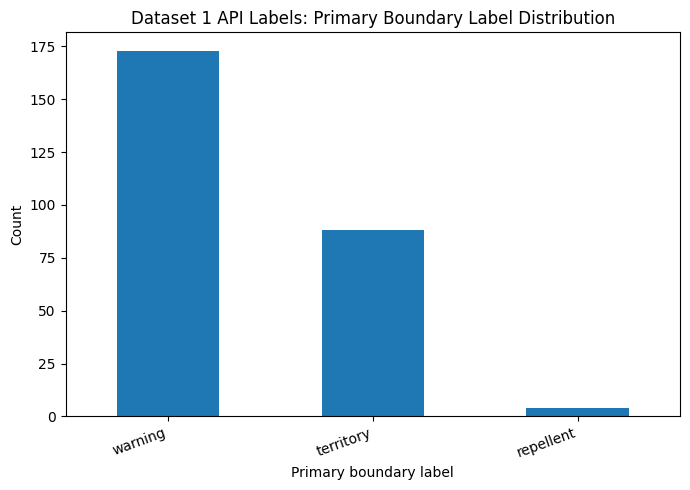

Saved file: .\outputs\plot_dataset1_api_primary_label_counts.png


In [27]:
import matplotlib.pyplot as plt

plot_primary = df_api_full_results_v2["primary_boundary_label"].value_counts()

plt.figure(figsize=(7, 5))
plot_primary.plot(kind="bar")
plt.title("Dataset 1 API Labels: Primary Boundary Label Distribution")
plt.xlabel("Primary boundary label")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plot_file_1 = os.path.join(outputs_dir, "plot_dataset1_api_primary_label_counts.png")
plt.savefig(plot_file_1, dpi=300, bbox_inches="tight")
plt.show()

print("Saved file:", plot_file_1)


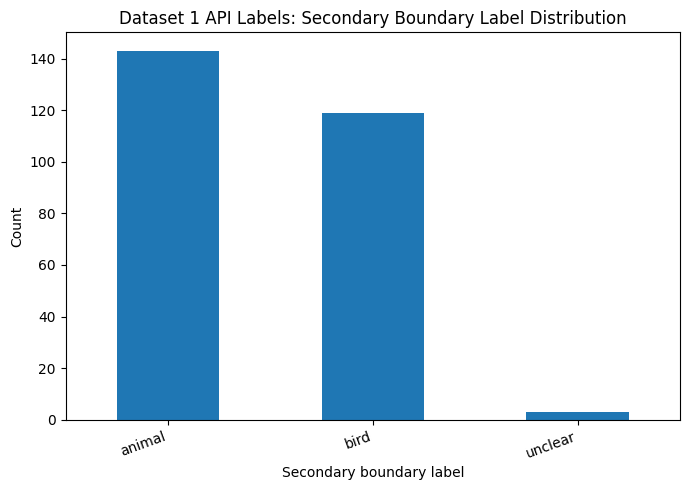

Saved file: .\outputs\plot_dataset1_api_secondary_label_counts.png


In [28]:
plot_secondary = df_api_full_results_v2["secondary_boundary_label"].value_counts()

plt.figure(figsize=(7, 5))
plot_secondary.plot(kind="bar")
plt.title("Dataset 1 API Labels: Secondary Boundary Label Distribution")
plt.xlabel("Secondary boundary label")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plot_file_2 = os.path.join(outputs_dir, "plot_dataset1_api_secondary_label_counts.png")
plt.savefig(plot_file_2, dpi=300, bbox_inches="tight")
plt.show()

print("Saved file:", plot_file_2)

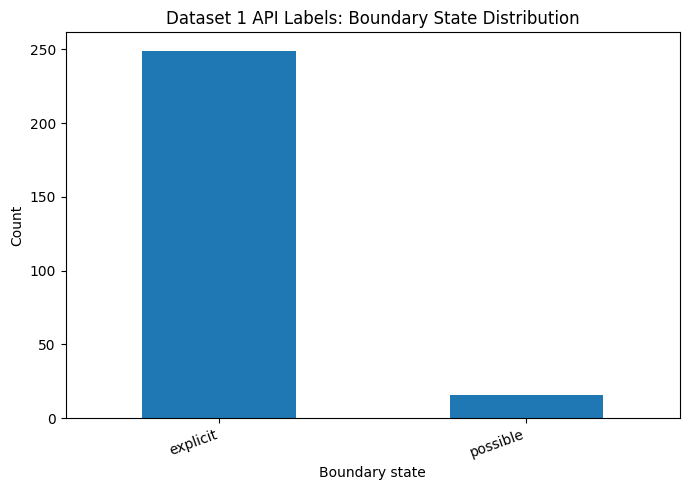

Saved file: .\outputs\plot_dataset1_api_boundary_state_counts.png


In [29]:
plot_state = df_api_full_results_v2["boundary_state"].value_counts()

plt.figure(figsize=(7, 5))
plot_state.plot(kind="bar")
plt.title("Dataset 1 API Labels: Boundary State Distribution")
plt.xlabel("Boundary state")
plt.ylabel("Count")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plot_file_3 = os.path.join(outputs_dir, "plot_dataset1_api_boundary_state_counts.png")
plt.savefig(plot_file_3, dpi=300, bbox_inches="tight")
plt.show()

print("Saved file:", plot_file_3)

In [30]:
cross_tab = pd.crosstab(
    df_api_full_results_v2["primary_boundary_label"],
    df_api_full_results_v2["secondary_boundary_label"]
)

display(cross_tab)

secondary_boundary_label,animal,bird,unclear
primary_boundary_label,,,
repellent,2,2,0
territory,56,32,0
warning,85,85,3


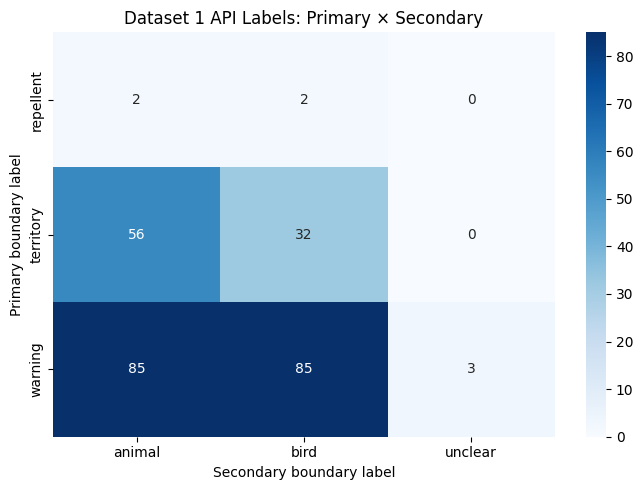

Saved file: .\outputs\plot_dataset1_api_primary_secondary_heatmap.png


In [31]:
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.heatmap(cross_tab, annot=True, fmt="d", cmap="Blues")
plt.title("Dataset 1 API Labels: Primary × Secondary")
plt.xlabel("Secondary boundary label")
plt.ylabel("Primary boundary label")
plt.tight_layout()

plot_file_4 = os.path.join(outputs_dir, "plot_dataset1_api_primary_secondary_heatmap.png")
plt.savefig(plot_file_4, dpi=300, bbox_inches="tight")
plt.show()

print("Saved file:", plot_file_4)

In [32]:
cross_tab_file = os.path.join(outputs_dir, "dataset1_api_primary_secondary_crosstab.csv")
cross_tab.to_csv(cross_tab_file, encoding="utf-8-sig")
print("Saved file:", cross_tab_file)

Saved file: .\outputs\dataset1_api_primary_secondary_crosstab.csv
